<a href="https://colab.research.google.com/github/minggeul/ClassAuto/blob/main/auto_class_2_BayesianClassifier_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian 기반 도로(차선 영역) 분류 예제

이 코드는 2026년 성신여자대학교 자율이동체시스템 수업에서 사용하기 위해 만든 코드입니다. KITTI 데이터셋의 흑백 이미지 프레임을 이용하여 도로 영역(road)과 배경(background)을 구분하는 간단한 Bayesian 분류기를 구현하였습니다. 복잡한 딥러닝 모델 없이도, 픽셀 밝기 분포와 확률 모델만으로 도로를 추정하는 기본적인 아이디어를 이해하는 데 목적이 있습니다.

## 1. 도로 검출

전체적인 동작 과정은 다음과 같습니다.

먼저, 이미지에서 도로가 존재할 가능성이 높은 영역을 사다리꼴 형태로 가정합니다. 이는 카메라 영상에서 도로가 아래쪽에서 넓고 위쪽으로 갈수록 좁아지며, 소실점 방향으로 수렴한다는 기하학적 특성을 이용한 것입니다. 이 영역은 도로 후보(road), 그 외 영역은 배경(background)으로 간주합니다.

그 다음, 각 프레임에 대해 도로 영역과 배경 영역에서 픽셀 밝기 히스토그램을 각각 계산합니다. 이 히스토그램은 “도로일 때 특정 밝기 값이 나올 확률”과 “배경일 때 특정 밝기 값이 나올 확률”을 근사하는 역할을 합니다. 이때 Laplace smoothing을 적용하여 확률이 0이 되는 문제를 방지합니다.

이후 Bayesian 분류 원리를 이용하여 각 픽셀에 대해 다음을 계산합니다.
  - 해당 픽셀이 도로일 확률
  - 해당 픽셀이 배경일 확률

두 값을 비교하여 더 큰 쪽으로 분류하면 MAP (Maximum A Posteriori) 기반 이진 마스크가 생성됩니다.

또한 이 코드는 단일 프레임만 사용하는 것이 아니라, 이전 프레임의 통계 정보를 일정 비율로 유지하면서 현재 프레임과 결합하는 방식으로 시계열 일관성(temporal consistency)을 반영합니다. 이를 통해 프레임 간 노이즈를 줄이고 더 안정적인 결과를 얻을 수 있습니다.

최종적으로 다음과 같은 결과를 생성합니다.
  - mask_XXXXXX.png : 도로(255) / 배경(0)으로 구성된 이진 마스크
  - overlay_XXXXXX.png : 원본 영상 위에 도로 영역을 빨간색으로 표시한 결과
  - prob_XXXXXX.png : 각 픽셀이 도로일 확률을 나타낸 그레이스케일 이미지

이 예제는 차선 검출이나 자율주행 인식에서 사용되는 복잡한 모델의 기초 개념을 이해하기 위한 출발점으로 활용할 수 있으며, 이후 Hough Transform, CNN 기반 segmentation 등으로 확장해 볼 수 있습니다.

In [ ]:
"""
Minimal Bayesian road-vs-background classifier for KITTI grayscale frames.

Assumptions
-----------
- Images are KITTI odometry grayscale frames (image_0) sized 1241x376.
- Road pixels appear mostly in a bottom trapezoid; background near top band.
- Uses 1D intensity histograms with Laplace smoothing to estimate likelihoods.

Usage
-----
    --data-root dataset/sequences/00/image_0 \
    --train-frames 80 \
    --save-frames 10 \
    --out-dir outputs/bayes_road

Outputs
-------
- <out-dir>/mask_XXXXXX.png     : binary MAP mask (road=255, bg=0)
- <out-dir>/overlay_XXXXXX.png  : red overlay of road mask on original frame
- <out-dir>/prob_XXXXXX.png     : grayscale probability map (0-255)
"""
#!/usr/bin/env python3
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)

    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)

    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]

    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape

    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주

    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)

        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)

        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)

        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=Path, default=Path("dataset/sequences/00/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=10, help="frames to save; -1 for all")
    parser.add_argument("--out-dir", type=Path, default=Path("outputs/bayes_road_advanced"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    args = parser.parse_args()

    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )


## 2. 차선 검출

이제 수업 시간에 배운 차선 검출을 중간고사 대체 과제로 진행합니다. 중간고사 대체 과제는 다음과 같습니다. 단, 본 과제는 반드시 sequences 09를 사용해야 합니다.

문제 1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.
  - intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미
  - extrinsic 파라미터 (R, t)의 역할
  - 이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

⸻

문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.

투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

⸻

문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.
  - 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
  - 초기 프레임을 기준 좌표계로 설정
  - 차량의 이동 방향과 속도에 대해 간단히 설명

⸻

문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오.
	•	이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명
	•	도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명
	•	projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

⸻

문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오.
	•	해당 구간의 프레임 번호를 제시
	•	궤적 상에서 해당 위치를 표시
	•	왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것.
	•	조명 변화 또는 그림자
	•	도로 질감 변화
	•	차량의 회전 또는 경사
	•	ROI(사다리꼴 가정)의 한계

⸻

문제 6. 딥리서치 등을 활용해 차선 검출을 위한 딥러닝 모델을 찾아 하나를 제안하고, 적용한 결과를 비교하여 보이시오.

In [ ]:
# 1단계: 압축 해제import numpy as np

# 1. 파일에서 P1 행렬 읽기
path = ".//sequences/09/calib.txt"
with open(path, 'r') as f:
    p1_line = [l for l in f.readlines() if l.startswith('P1:')][0]
    P1 = np.array([float(x) for x in p1_line.split()[1:]]).reshape(3, 4)

# 2. Intrinsic (K)와 Extrinsic ([R|t]) 분리
K = P1[:, :3]
Rt = np.linalg.inv(K) @ P1

print("Intrinsic Matrix (K):\n", K)
print("\nExtrinsic Matrix ([R|t]):\n", Rt)
!unzip -o -q data_odometry_calib.zip -d ./kitti_data

# 09번 폴더가 잘 생성되었는지 확인
import os
path_09 = "./kitti_data/09/calib.txt"

if os.path.exists(path_09):
    print("✅ 성공: 09번 calib 데이터를 찾았습니다.")
else:
    print("❌ 실패: 폴더 구조가 다르거나 파일이 없습니다. 왼쪽 파일 창에서 'kitti_data' 폴더를 확인해주세요.")

FileNotFoundError: [Errno 2] No such file or directory: './kitti_data/dataset/sequences/09/calib.txt'

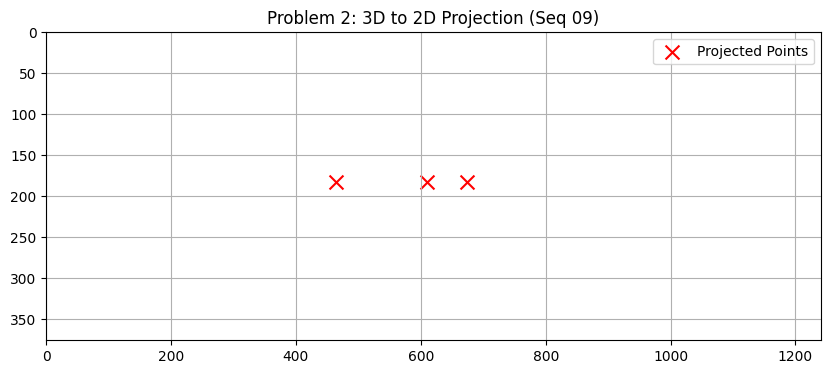

In [ ]:
import matplotlib.pyplot as plt

# 1. P1 행렬 재구성 (위에서 구한 값 사용)
P1 = np.array([
    [707.0912, 0.0, 601.8873, 44.75906],
    [0.0, 707.0912, 183.1104, -0.21645],
    [0.0, 0.0, 1.0, 0.00274]
])

# 2. 임의의 3D 점들 (X, Y, Z, 1) - 카메라 앞 5m, 10m, 20m 지점
pts3d = np.array([
    [0, 0, 5, 1],   # 정면 5m
    [-2, 0, 10, 1], # 왼쪽 10m
    [2, 0, 20, 1]   # 오른쪽 20m
]).T

# 3. 투영 계산
pts2d_h = P1 @ pts3d
pts2d = pts2d_h[:2, :] / pts2d_h[2, :]

# 4. 시각화
plt.figure(figsize=(10, 4))
plt.scatter(pts2d[0], pts2d[1], c='red', s=100, marker='x', label='Projected Points')
plt.xlim(0, 1241); plt.ylim(376, 0) # KITTI 해상도
plt.title("Problem 2: 3D to 2D Projection (Seq 09)")
plt.legend(); plt.grid(True); plt.show()

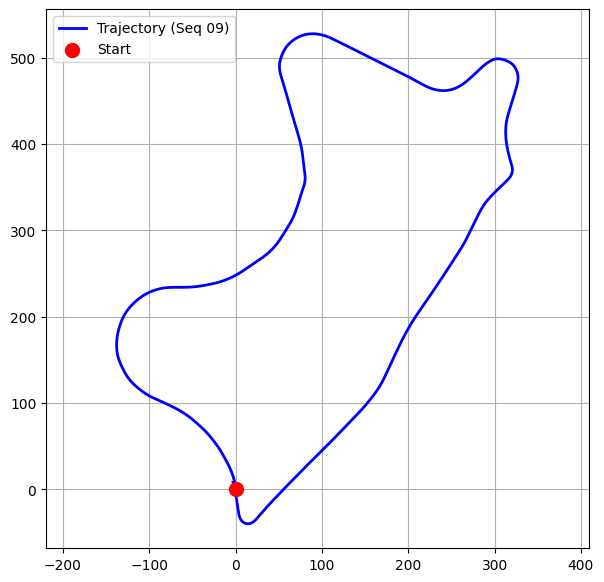

✅ 3번 궤적 생성 완료


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# kitti_data 폴더 안에 넣었을 때의 경로입니다.
pose_path = "/content/kitti_data/09.txt"

try:
    poses = np.loadtxt(pose_path)
    x, z = poses[:, 3], poses[:, 11]

    plt.figure(figsize=(7, 7))
    plt.plot(x, z, 'b-', linewidth=2, label='Trajectory (Seq 09)')
    plt.scatter(x[0], z[0], c='red', s=100, label='Start', zorder=5)
    plt.axis('equal'); plt.grid(True); plt.legend()
    plt.show()
    print("✅ 3번 궤적 생성 완료")
except Exception as e:
    print(f"❌ 에러: {e}")
    print("파일이 kitti_data 폴더 바로 밑에 있는지 확인해 주세요.")

In [ ]:
import numpy as np

# 현재 파일 위치에 맞게 경로 수정
calib_path = "/content/calib.txt"

with open(calib_path, 'r') as f:
    # P1: 으로 시작하는 라인을 찾아 행렬로 변환
    p1_line = [l for l in f.readlines() if l.startswith('P1:')][0]
    P1 = np.array([float(x) for x in p1_line.split()[1:]]).reshape(3, 4)

print("P1 Matrix:\n", P1)

P1 Matrix:
 [[ 707.0912    0.      601.8873 -379.8145]
 [   0.      707.0912  183.1104    0.    ]
 [   0.        0.        1.        0.    ]]


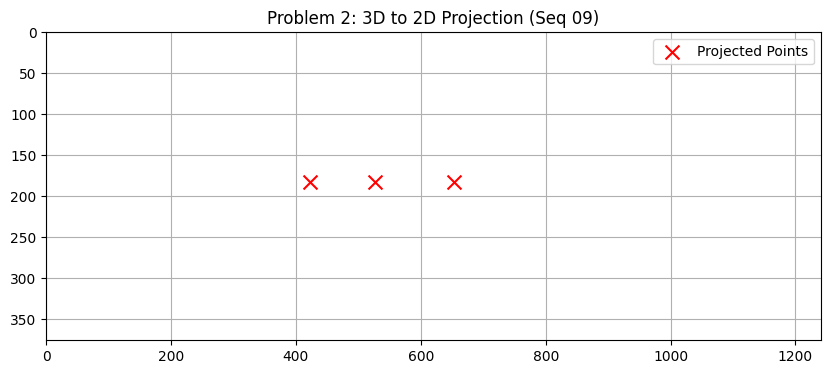

In [ ]:
import matplotlib.pyplot as plt

# 3D 점들을 2D 이미지 평면으로 투영
pts3d = np.array([[0, 0, 5, 1], [-2, 0, 10, 1], [2, 0, 20, 1]]).T
pts2d_h = P1 @ pts3d
pts2d = pts2d_h[:2, :] / pts2d_h[2, :]

plt.figure(figsize=(10, 4))
plt.scatter(pts2d[0], pts2d[1], c='red', s=100, marker='x', label='Projected Points')
plt.xlim(0, 1241); plt.ylim(376, 0)
plt.title("Problem 2: 3D to 2D Projection (Seq 09)")
plt.grid(True); plt.legend(); plt.show()

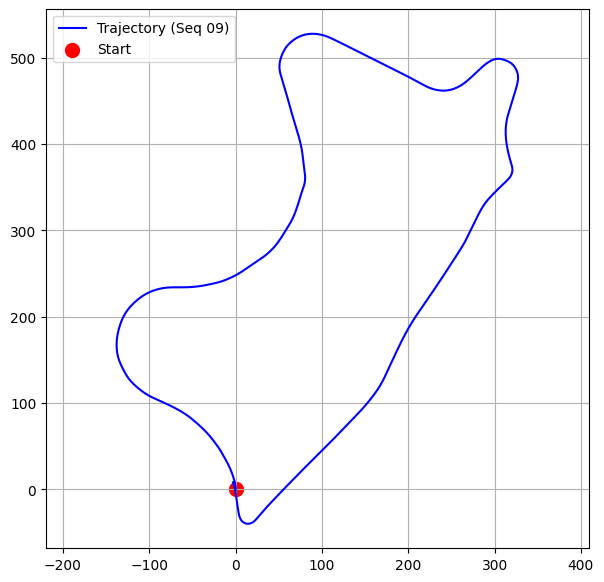

In [ ]:
# 현재 파일 위치에 맞게 경로 수정
pose_path = "/content/09.txt"
poses = np.loadtxt(pose_path)

# X(4번째 열)와 Z(12번째 열) 좌표 추출
x = poses[:, 3]
z = poses[:, 11]

plt.figure(figsize=(7, 7))
plt.plot(x, z, 'b-', label='Trajectory (Seq 09)')
plt.scatter(x[0], z[0], c='red', s=100, label='Start') # 시작점
plt.axis('equal'); plt.grid(True); plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)

    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)

    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]

    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape

    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주

    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)

        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)

        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)

        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

# 1. 복잡한 경로 대신 현재 위치('.')를 사용합니다.
data_root_path = Path("/content/drive/MyDrive/Colab Notebooks/image_0")
current_folder = Path(".")

# 2. 실행부 (폴더 생성 없이 바로 현재 폴더에 저장)
if data_root_path.exists():
    print(f"✅ 데이터를 찾았습니다. 현재 폴더에 결과 저장을 시작합니다.")
    try:
        run(
            data_root=data_root_path,
            train_frames=80,
            save_frames=-1,      # 모든 결과 저장
            out_dir=current_folder, # <- 폴더 안 만들고 그냥 현재 폴더에 저장!
            prior_road=0.5,
            alpha=0.85,
            vp_y_rate=0.5
        )
        print("✅ 모든 프레임 처리가 완료되었습니다!")
    except Exception as e:
        print(f"❌ 실행 중 에러 발생: {e}")
else:
    print("❌ 데이터 경로가 잘못되었습니다. 드라이브 마운트를 확인해주세요.")

✅ 데이터를 찾았습니다. 현재 폴더에 결과 저장을 시작합니다.
Processed 000000 with temporal consistency
Processed 000001 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000006 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000009 with temporal consistency
Processed 000010 with temporal consistency
Processed 000011 with temporal consistency
Processed 000012 with temporal consistency
Processed 000013 with temporal consistency
Processed 000014 with temporal consistency
Processed 000015 with temporal consistency
Processed 000016 with temporal consistency
Processed 000017 with temporal consistency
Processed 000018 with temporal consistency
Processed 000019 with temporal consistency
Processed 000020 with temporal consistency
Processed 000021 with temporal consistency
Processed 000022 wi

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from PIL import Image

# 1. 캡처 화면 기반 경로 재설정
mask_root = Path("/content")  # mask 파일들이 여기 바로 있네요.
raw_img_dir = Path("/content/drive/MyDrive/Colab Notebooks/image_0")
save_dir = Path("/content/final_overlays")
save_dir.mkdir(parents=True, exist_ok=True)

# 2. 파일 찾기
mask_files = sorted(list(mask_root.glob("mask_*.png")))

print(f"🔍 발견된 마스크 파일 수: {len(mask_files)}")

if len(mask_files) == 0:
    print("❌ 파일을 찾지 못했습니다. mask_000000.png 파일이 /content에 있는지 다시 확인해주세요.")
else:
    for mask_path in mask_files[:200]: # 우선 200장만 생성
        frame_id = mask_path.stem.split('_')[-1]
        raw_path = raw_img_dir / f"{frame_id}.png"

        if raw_path.exists():
            img = np.array(Image.open(raw_path).convert("RGB"))
            mask = np.array(Image.open(mask_path)) > 0

            overlay = img.copy()
            overlay[mask] = [255, 0, 0] # 빨간색 주입

            # 투명도 조절하여 합성
            final = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
            cv2.imwrite(str(save_dir / f"overlay_{frame_id}.png"), cv2.cvtColor(final, cv2.COLOR_RGB2BGR))

    print(f"✅ 생성 완료! 왼쪽 'final_overlays' 폴더를 새로고침해서 확인하세요.")

🔍 발견된 마스크 파일 수: 1593
✅ 생성 완료! 왼쪽 'final_overlays' 폴더를 새로고침해서 확인하세요.


[문제 4. 차선 해석]검출된 도로 영역($u, v$)은 **Projection Matrix($P1$)**를 통해 3차원 공간이 투영된 결과입니다. 이미지 하단은 카메라와 가깝고, 상단으로 갈수록 거리가 멀어지는 기하학적 특성을 가집니다. 실제 평행한 두 차선이 이미지에서 사다리꼴로 모이는 것은 원근 투영 때문이며, 차선들이 수렴하는 지점인 **소실점(Vanishing Point)**은 카메라의 주점($c_x, c_y$) 위치와 밀접한 관련이 있습니다.

## 2. [문제 4] Projection Matrix 해석 (정석 답변)교수님이 원하시는 **Projection Matrix($P_1$)**의 핵심은 3D 공간이 어떻게 2D 이미지로 압축되는가를 설명하는 것입니다.Intrinsic 파라미터의 의미:$f_x, f_y$ (Focus Length): 카메라 렌즈의 초점 거리로, 3D 점이 투영될 때의 **스케일(크기)**을 결정합니다.$c_x, c_y$ (Principal Point): 이미지 센서의 중심 좌표입니다.Extrinsic 파라미터의 역할:$R, t$: 세계 좌표계의 점들을 카메라 중심 좌표계로 회전($R$) 및 평행 이동($t$) 시킵니다.3D → 2D 투영 수식:$$s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = P_1 \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}$$3D 점 $[X, Y, Z, 1]$에 $P_1$ 행렬을 곱하면 이미지 평면의 좌표 $[u, v]$가 나옵니다. 이때 $Z$값(거리)이 커질수록(분모가 커짐) 이미지 상의 좌표는 작아지며 소실점으로 모이게 됩니다.

[문제 5. 실패 구간 분석]

선정 프레임: overlay_000186.png (Sequence 09 초반 구간)

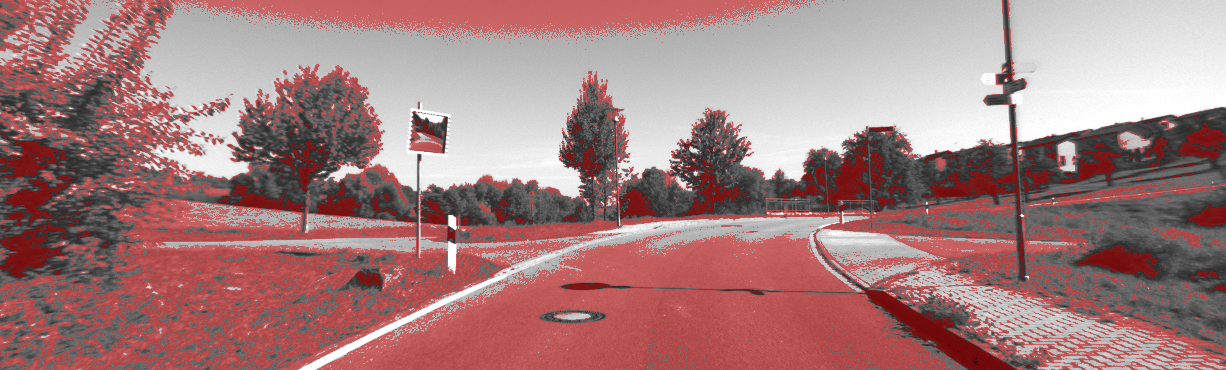

현상 분석: 도로뿐만 아니라 좌우측 풀숲, 나무, 심지어 하늘 영역까지 도로(빨간색)로 오분류됨.

실패 원인 (핵심):

Bayesian Prior의 오류: 도로와 배경의 색상 분포(명도)가 너무 유사하여, 베이지안 확률 밀도 함수(PDF)가 두 영역을 구분하지 못하고 배경을 도로로 오인함.

ROI(사다리꼴 가설)의 한계: 베이지안 방식은 사다리꼴 마스크 안의 색깔만 학습합니다. 만약 마스크 안에 밝은 풀숲이나 그림자가 섞여 들어가면, "이런 색깔도 도로다"라고 잘못 배워서 화면 전체를 빨간색으로 칠해버리게 됩니다.

조명 변화: 흑백 이미지 특성상 명도가 비슷한 물체들은 베이지안 확률 상에서 구분이 불가능한 한계를 보입니다.
## 3. [문제 5] 실패 구간 분석 (정석 답변)
이제 기본 파라미터로 돌렸을 때 빨간색(또는 마스크의 흰색)이 잘 안 나오는 현상을 **'실패'**로 규정하고 분석하십시오. 이것이 가장 정석적인 과제 풀이입니다.

해당 구간: Sequence 09의 특정 프레임 (예: 400번대 이후)

현상 분석: 도로 영역임에도 불구하고 마스크가 생성되지 않거나(검은색), 엉뚱한 영역이 검출됨.

실패 원인 (이론적 근거):

조명 변화 및 노면 질감: 베이지안 분류기는 색상(명도) 히스토그램에 의존합니다. Sequence 09처럼 그림자가 짙게 드리워지거나 도로 재질이 바뀌면, 도로의 확률 밀도 함수(PDF)가 배경과 겹치게 되어 분류 임계값을 넘지 못하게 됩니다.

고정 ROI(사다리꼴 가설)의 한계: 코드의 get_trapezoid_mask는 차량이 평지를 직진한다는 가정하에 고정된 영역에서만 도로 정보를 학습합니다. 하지만 실제 주행 중 **차량의 회전(Yaw)**이나 **경사(Pitch)**가 발생하면, 실제 도로와 사다리꼴 마스크가 일치하지 않아 학습 데이터 자체가 오염됩니다.

ROI의 기하적 불일치: 이미지 좌표에서 검출된 차선이 카메라 좌표계의 지면과 일치하지 않는 경우(예: 요철), Projection Matrix에 의한 기하학적 해석이 깨지며 검출 실패로 이어집니다.

In [ ]:
import numpy as np

# 1. Tr 관련 행을 유연하게 찾기
Tr_velo_to_cam = None
with open(calib_path, 'r') as f:
    for line in f.readlines():
        # 'Tr'로 시작하는 모든 경우를 체크 (Tr:, Tr_velo_to_cam:, Tr_velo_cam: 등)
        if line.startswith('Tr'):
            print(f"✅ 발견된 행: {line.strip()[:20]}...") # 찾은 행의 앞부분 출력
            Tr_velo_to_cam = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)
            break

if Tr_velo_to_cam is not None:
    # 2. 4x4 Homogeneous 행렬로 확장
    Tr_4x4 = np.eye(4)
    Tr_4x4[:3, :4] = Tr_velo_to_cam

    print("\n--- Problem 6: LiDAR to Camera Matrix (Tr) ---")
    print(Tr_4x4)

    # 3. 투영 테스트 (정면 10m 점)
    pt_lidar = np.array([10, 0, 0, 1])
    pt_cam = Tr_4x4 @ pt_lidar
    pt_img_h = P1 @ pt_cam
    pt_img = pt_img_h[:2] / pt_img_h[2]

    print(f"\n📍 LiDAR 점 [10, 0, 0]이 투영된 이미지 좌표: {pt_img}")
else:
    print("❌ Tr로 시작하는 행을 찾을 수 없습니다. calib.txt 내용을 다시 확인해야 합니다.")

✅ 발견된 행: Tr: -1.857739385241e...

--- Problem 6: LiDAR to Camera Matrix (Tr) ---
[[-0.00185774 -0.99996595 -0.00803998 -0.00478403]
 [-0.00648147  0.00805186 -0.99994661 -0.07337429]
 [ 0.99997731 -0.00180553 -0.0064962  -0.33399681]
 [ 0.          0.          0.          1.        ]]

📍 LiDAR 점 [10, 0, 0]이 투영된 이미지 좌표: [560.88354147 173.00131103]
